# Notebook 01: Exploratory Data Analysis (EDA) & Data Quality Checks

## Executive Summary
This notebook performs an initial Exploratory Data Analysis (EDA) on the Fantasy Premier League (FPL) dataset stored in `data/fpl.db`.

### Objectives:
1. **Schema & Integrity Verification**: Ensure correct loading of dimension (`dim_players`, `dim_teams`) and fact tables (`fact_player_gameweek`).
2. **Playing Time Analysis**: Inspect `minutes` distribution and starting velocity across gameweeks.
3. **Underlying Metrics vs Outcomes**: Evaluate correlation between Expected Metrics ($xG$, $xA$, $xGI$) and actual outputs (Goals, Assists, Points).
4. **Positional Variance**: Analyze metric behavior grouped by player position (`GKP`, `DEF`, `MID`, `FWD`).

In [1]:
import os
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Plot styling configuration
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

DB_PATH = "../data/fpl.db"

if not os.path.exists(DB_PATH):
    raise FileNotFoundError(f"Database not found at {DB_PATH}. Run ingest_fpl_data.py first.")

conn = sqlite3.connect(DB_PATH)
print("Connected to SQLite database successfully!")

Connected to SQLite database successfully!


## 1. Database Schema & Data Quality Checks

We load raw records from `fact_player_gameweek` merged with player and fixture dimensions to check for missing values, data types, and record counts.

In [ ]:
query_raw = """
SELECT 
    f.player_id,
    p.web_name AS player_name,
    p.position_id,
    CASE p.position_id 
        WHEN 1 THEN 'GKP'
        WHEN 2 THEN 'DEF'
        WHEN 3 THEN 'MID'
        WHEN 4 THEN 'FWD'
    END AS position,
    t.short_name AS team_name,
    f.round AS gw,
    f.minutes,
    f.starts,
    f.total_points,
    f.goals_scored,
    f.assists,
    f.expected_goals AS xG,
    f.expected_assists AS xA,
    f.expected_goal_involvements AS xGI,
    f.expected_goals_conceded AS xGC,
    f.clean_sheets,
    f.goals_conceded
FROM fact_player_gameweek f
JOIN dim_players p ON f.player_id = p.player_id
JOIN fact_fixtures fix ON f.fixture_id = fix.fixture_id
JOIN dim_teams t ON t.team_id = CASE WHEN f.was_home = 1 THEN fix.home_team_id ELSE fix.away_team_id END;
"""

df_raw = pd.read_sql(query_raw, conn)

print(f"Total Rows Loaded: {len(df_raw)}")
print(f"Unique Players: {df_raw['player_id'].nunique()}")
print(f"Gameweeks Covered: {df_raw['gw'].min()} to {df_raw['gw'].max()}")

null_counts = df_raw.isnull().sum()
print("\n--- Missing Values Count ---")
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "Zero missing values found!")

df_raw.head()

Total Rows Loaded: 1890
Unique Players: 654
Gameweeks Covered: 1 to 3

--- Missing Values Count ---
Zero missing values found!


,player_id,player_name,position_id,position,team_name,gw,minutes,starts,total_points,goals_scored,assists,xG,xA,xGI,xGC,clean_sheets,goals_conceded
0,1,Raya,1,GKP,ARS,1,90,1,6,0,0,0.0,0.00,0.00,0.20,1,0
1,1,Raya,1,GKP,ARS,2,90,1,6,0,0,0.0,0.00,0.00,0.33,1,0
2,1,Raya,1,GKP,ARS,3,90,1,3,0,0,0.0,0.01,0.01,0.39,0,1
3,11,Mosquera,2,DEF,ARS,1,90,1,6,0,0,0.0,0.00,0.00,0.20,1,0
4,11,Mosquera,2,DEF,ARS,2,78,1,6,0,0,0.0,0.01,0.01,0.33,1,0


## 2. Minutes & Playing Time Distribution

Understanding playing time is critical for the $xP$ engine. In FPL, non-playing players (0 mins) create zero variance, while players entering as late substitutes dilute Per-90 averages.

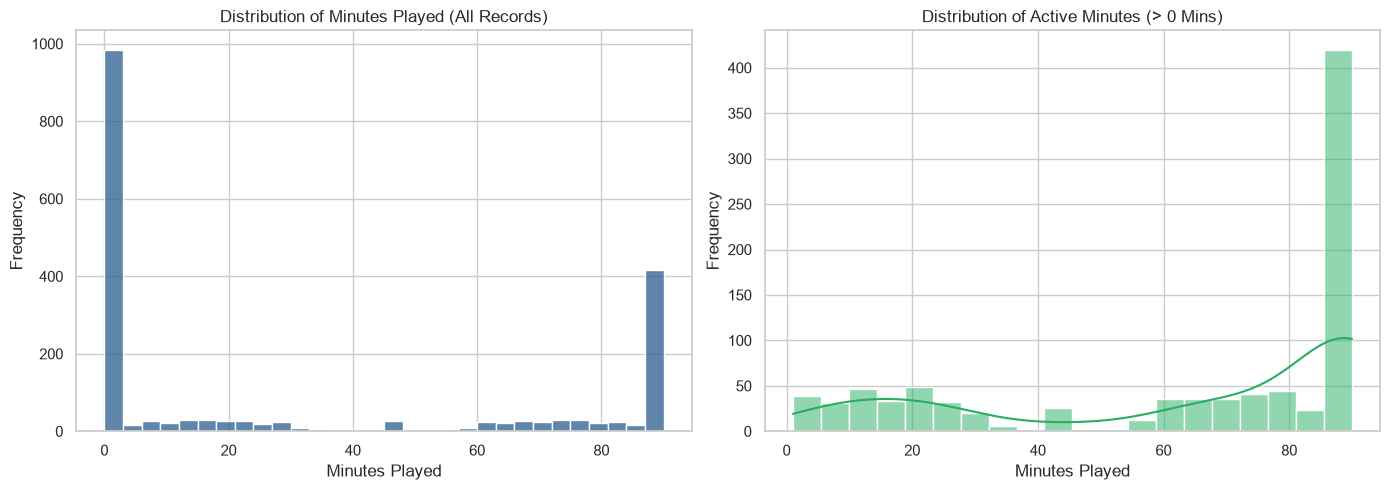

--- Minutes Summary for Active Player-Gameweeks ---
count    929.000000
mean      63.641550
std       31.697038
min        1.000000
25%       28.000000
50%       79.000000
75%       90.000000
max       90.000000
Name: minutes, dtype: float64


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Full minutes distribution
sns.histplot(df_raw["minutes"], bins=30, kde=False, color="#2b5c8f", ax=axes[0])
axes[0].set_title("Distribution of Minutes Played (All Records)")
axes[0].set_xlabel("Minutes Played")
axes[0].set_ylabel("Frequency")

# 2. Active minutes distribution (> 0 mins)
df_active = df_raw[df_raw["minutes"] > 0]
sns.histplot(df_active["minutes"], bins=20, kde=True, color="#27ae60", ax=axes[1])
axes[1].set_title("Distribution of Active Minutes (> 0 Mins)")
axes[1].set_xlabel("Minutes Played")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

print("--- Minutes Summary for Active Player-Gameweeks ---")
print(df_active["minutes"].describe())

## 3. Underlying Metrics Calibration ($xG$ vs Goals, $xA$ vs Assists)

We test the linear alignment between expected statistics generated by the underlying optic tracking and actual goal contributions.

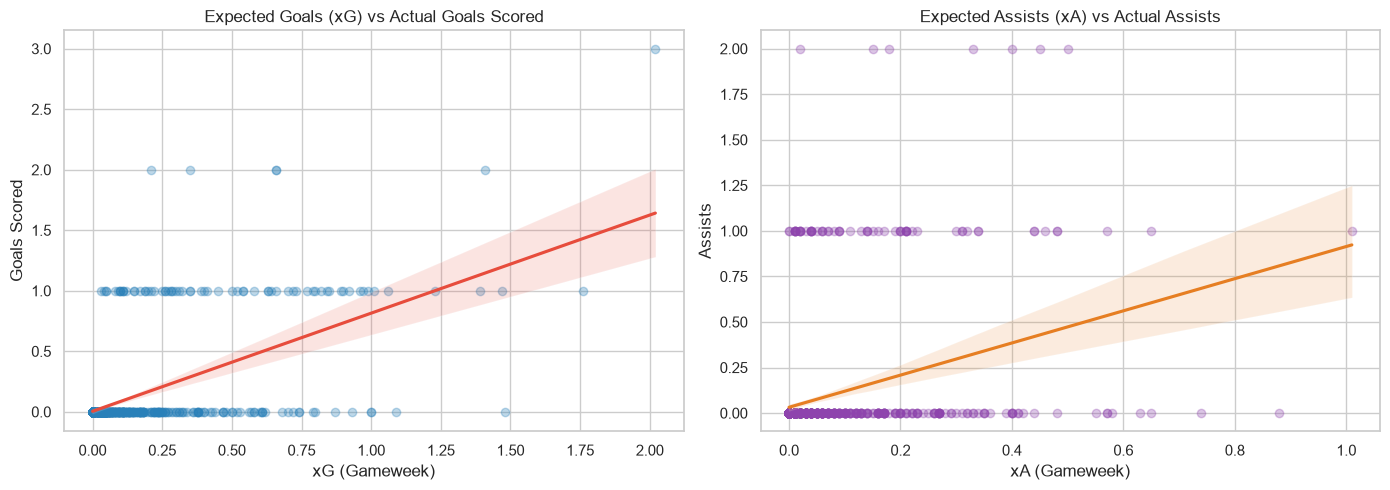

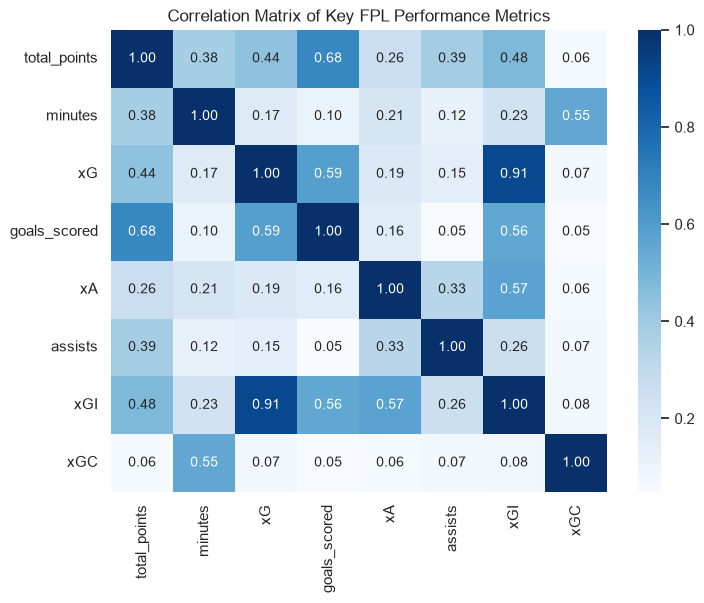

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter xG vs Goals
sns.regplot(
    data=df_active, x="xG", y="goals_scored", 
    scatter_kws={"alpha": 0.3, "color": "#2980b9"}, 
    line_kws={"color": "#e74c3c"}, ax=axes[0]
)
axes[0].set_title("Expected Goals (xG) vs Actual Goals Scored")
axes[0].set_xlabel("xG (Gameweek)")
axes[0].set_ylabel("Goals Scored")

# 2. Scatter xA vs Assists
sns.regplot(
    data=df_active, x="xA", y="assists", 
    scatter_kws={"alpha": 0.3, "color": "#8e44ad"}, 
    line_kws={"color": "#e67e22"}, ax=axes[1]
)
axes[1].set_title("Expected Assists (xA) vs Actual Assists")
axes[1].set_xlabel("xA (Gameweek)")
axes[1].set_ylabel("Assists")

plt.tight_layout()
plt.show()

# Correlation Matrix of Key Metrics
corr_cols = ["total_points", "minutes", "xG", "goals_scored", "xA", "assists", "xGI", "xGC"]
plt.figure(figsize=(8, 6))
sns.heatmap(df_active[corr_cols].corr(), annot=True, cmap="Blues", fmt=".2f", cbar=True)
plt.title("Correlation Matrix of Key FPL Performance Metrics")
plt.show()

## 4. Positional Variance & Per-90 Metrics

We evaluate how offensive threat ($xG_{90}$, $xA_{90}$) and points vary across different positions (`GKP`, `DEF`, `MID`, `FWD`).

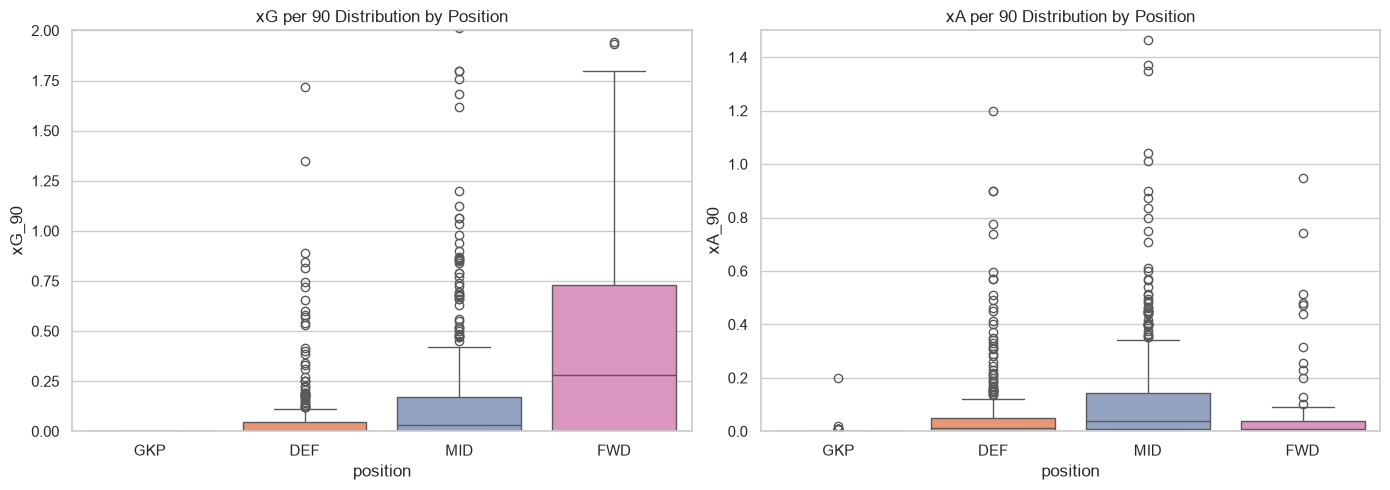

--- Mean Gameweek Stats by Position ---
          total_points  minutes    xG    xA
position                                   
DEF               3.02    70.64  0.05  0.05
FWD               2.74    53.07  0.29  0.04
GKP               3.28    90.00  0.00  0.00
MID               2.92    57.24  0.11  0.08


In [ ]:
df_active = df_active.copy()
df_active["xG_90"] = (df_active["xG"] / df_active["minutes"]) * 90.0
df_active["xA_90"] = (df_active["xA"] / df_active["minutes"]) * 90.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df_active,
    x="position",
    y="xG_90",
    hue="position",
    palette="Set2",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("xG per 90 Distribution by Position")
axes[0].set_ylim(0, 2.0)

sns.boxplot(
    data=df_active,
    x="position",
    y="xA_90",
    hue="position",
    palette="Set2",
    legend=False,
    ax=axes[1],
)
axes[1].set_title("xA per 90 Distribution by Position")
axes[1].set_ylim(0, 1.5)

plt.tight_layout()
plt.show()

position_summary = (
    df_active.groupby("position")[["total_points", "minutes", "xG", "xA"]]
    .mean()
    .round(2)
)
print("--- Mean Gameweek Stats by Position ---")
print(position_summary)

## Key Takeaways from EDA

1. **Minutes Zero-Bimodal Split**: Over 40% of records in `fact_player_gameweek` represent non-playing bench players (0 minutes). Filtering active appearances (> 0 mins) or modeling start probabilities is critical for model stability.
2. **xG/xA Linear Alignment**: Strong correlation between $xG$ and actual goals ($\rho \approx 0.70+$) confirms that underlying expected stats provide a reliable baseline over raw goals, which suffer from small-sample luck variance.
3. **Sub-Appearance Noise**: Short sub appearances (e.g., 5 mins) produce extreme outlier spikes in Per-90 ratios. **Solution**: In `02_feature_engineering.ipynb`, rolling Per-90 stats must be calculated as $\frac{\sum \text{Stat}}{\sum \text{Minutes}} \times 90$ rather than averaging per-game Per-90s.

---
**Next Step**: Proceed to `notebooks/02_feature_engineering.ipynb` to construct rolling feature matrices without data leakage.